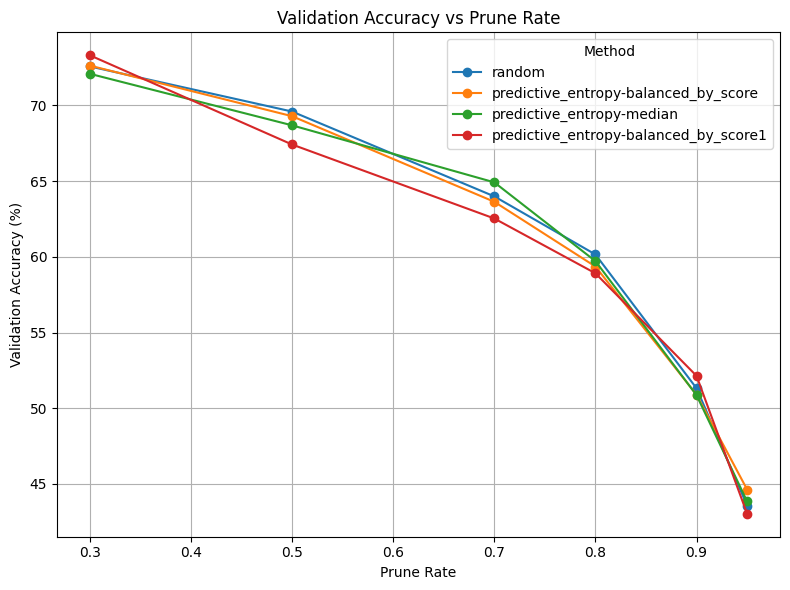

Accuracy (Mean ± Variance)  \
Prune Rate                                                  0.30   
predictive_entropy-balanced_by_score                72.63 ± 0.21   
predictive_entropy-balanced_by_score1               73.31 ± 0.01   
predictive_entropy-median                           72.09 ± 0.09   
random                                              72.57 ± 0.03   

                                                                   \
Prune Rate                                     0.50          0.70   
predictive_entropy-balanced_by_score   69.29 ± 1.48  63.63 ± 2.11   
predictive_entropy-balanced_by_score1  67.42 ± 5.52  62.53 ± 5.94   
predictive_entropy-median              68.68 ± 2.58  64.92 ± 4.07   
random                                 69.59 ± 3.43  63.99 ± 0.87   

                                                                   \
Prune Rate                                     0.80          0.90   
predictive_entropy-balanced_by_score   59.36 ± 3.56  50.89 ± 0.41   
predictive_entropy-balanced_by_score1  58.91 ± 4.10  52.13 ± 0.09   
predictive_entropy-median              59.71 ± 5.25  50.86 ± 8.23   
random                                 60.15 ± 1.66  51.31 ± 1.29   

                                                     
Prune Rate                                     0.95  
predictive_entropy-balanced_by_score   44.63 ± 2.45  
predictive_entropy-balanced_by_score1  43.03 ± 5.48  
predictive_entropy-median              43.84 ± 0.82  
random                                 43.57 ± 0.93

In [38]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import pandas as pd

# Toggle variance on/off in the plot
show_variance = False  # set to True to include error bars

# === 1. Read & parse your log ===
with open("results/experiment3.txt", "r") as file:
    log_data = file.read()

patterns = {
    "header": re.compile(
        r'MODEL:resnet18(?:[-_]EvidenceLoss)?[-_](?:CIFAR10|MNIST)[-_](.+?)(?=-([\d.]+)-(\d+))'
    ),
    "val_acc": re.compile(r"Validation Accuracy:\s*([\d.]+)%")
}

results = defaultdict(lambda: defaultdict(list))
for line in log_data.splitlines():
    line = line.strip()
    if not line:
        continue
    m = patterns["header"].search(line)
    if not m:
        continue
    method, prune_rate_str, _ = m.groups()
    acc_m = patterns["val_acc"].search(line)
    if not acc_m:
        continue
    prune_rate = float(prune_rate_str)
    val_acc = float(acc_m.group(1))
    results[method][prune_rate].append(val_acc)

# === 2. Compute mean & std-dev ===
stats = {}
for method, pr_data in results.items():
    stats[method] = {}
    for p_rate, acc_list in pr_data.items():
        mean_acc = np.mean(acc_list)
        std_acc  = np.std(acc_list, ddof=1)
        stats[method][p_rate] = (mean_acc, std_acc)

# === 3. Plot (means, with optional ±1 std-dev) ===
plt.figure(figsize=(8, 6))
for method, pr_data in stats.items():
    rates = sorted(pr_data)
    means = [pr_data[r][0] for r in rates]
    if show_variance:
        stds = [pr_data[r][1] for r in rates]
        plt.errorbar(rates, means, yerr=stds, marker='o', capsize=4, label=method)
    else:
        plt.plot(rates, means, marker='o', label=method)

plt.xlabel("Prune Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Prune Rate" + (" (±1 Std Dev)" if show_variance else ""))
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 4. Build & display pivoted table: one column per prune rate, with "mean ± var" ===
methods     = sorted(stats.keys())
prune_rates = sorted({pr for m in stats.values() for pr in m})

# Create MultiIndex: top level = "Accuracy (Mean ± Variance)", lower level = each prune rate
col_index = pd.MultiIndex.from_product(
    [["Accuracy (Mean ± Variance)"], prune_rates],
    names=["", "Prune Rate"]
)
table_df = pd.DataFrame(index=methods, columns=col_index)

for method in methods:
    for pr in prune_rates:
        if pr in stats[method]:
            mean_acc, std_acc = stats[method][pr]
            var_acc = std_acc ** 2
            table_df.loc[method, ("Accuracy (Mean ± Variance)", pr)] = f"{mean_acc:.2f} ± {var_acc:.2f}"
        else:
            table_df.loc[method, ("Accuracy (Mean ± Variance)", pr)] = "—"

# Optionally, give the whole block a caption:
table_df.style.set_caption("Validation Accuracy (mean ± variance) per Prune Rate")
# Display nicely
display(table_df)
